## Generate a sinthetic data to work

In [151]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
import porespy as ps

In [152]:
import porespy as ps

# Generate a synthetic 2D porous material image
im = ps.generators.blobs(shape=[300, 300], porosity=0.28, blobiness=1)
im = im.astype('uint8')
# Threshold the image to separate void space and solid matrix
threshold_value = 0.5  # Adjust this threshold as needed
#binary_image = (im > threshold_value).astype(int)
binary_image = im > threshold_value
# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

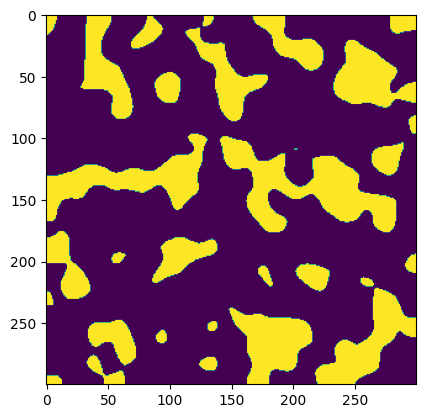

In [153]:
plt.imshow(im)

## Loading a real data

In [3]:
import numpy as np
import os
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

In [4]:
im_or = cv2.imread("PirabasB_2 - Copy.tif")

In [5]:
im_or.shape, im_or.dtype

((768, 1024, 3), dtype('uint8'))

In [6]:
im_or = im_or[:, :, 0]

In [7]:
im_or.shape, im_or.dtype

((768, 1024), dtype('uint8'))

In [9]:
# Dividindo a imagem em 4 quadrantes
height, width = im_or.shape
half_height, half_width = height // 2, width // 2

# Quadrantes
top_left = im_or[:half_height, :half_width]
top_right = im_or[:half_height, half_width:]
bottom_left = im_or[half_height:, :half_width]
bottom_right = im_or[half_height:, half_width:]

# Verificando as formas dos quadrantes
print("Top Left Shape:", top_left.shape)
print("Top Right Shape:", top_right.shape)
print("Bottom Left Shape:", bottom_left.shape)
print("Bottom Right Shape:", bottom_right.shape)

Top Left Shape: (384, 512)
Top Right Shape: (384, 512)
Bottom Left Shape: (384, 512)
Bottom Right Shape: (384, 512)


In [10]:
im = top_left

In [11]:
im.min(), im.max()

(0, 255)

In [12]:
im = (im - im.min())/ (im.max() - im.min()) 

In [15]:
im.max(), im.min(), im.shape

(1.0, 0.0, (384, 512))

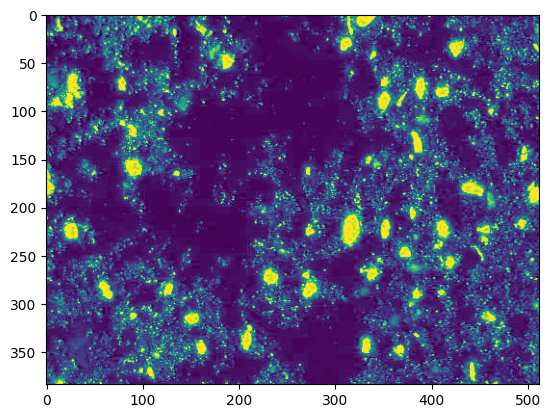

In [16]:
plt.imshow(im)
plt.show()

In [17]:
# Set the pore to be the value 1 # foreground
# This function is to create the binary image to the recognition process work
def create_binary_adjust_1(img):    
    import cv2
    # Convert the image to grayscale
    #gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply a threshold to the grayscale image
    #threshold_value = 25 # The ideal value
    thresold_value = 0.25
    max_value = 1
    #ret, binary = cv2.threshold(img, threshold_value, max_value, cv2.THRESH_BINARY_INV)
    ret, binary = cv2.threshold(img, thresold_value, max_value, cv2.THRESH_BINARY)
    return binary
# That's my case

In [18]:
binary_image = create_binary_adjust_1(im)

# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

In [19]:
binary_image.shape, binary_image.min(), binary_image.max()

((384, 512), 0.0, 1.0)

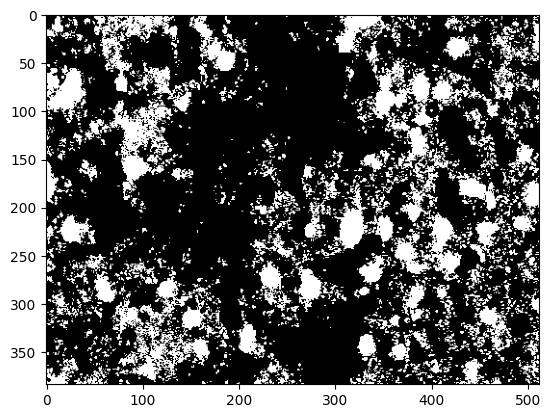

In [20]:
plt.imshow(binary_image, cmap='gray')

## save the segmented regions

In [21]:
# Lista para salvar as regiões segmentadas (void space)
regioes_segmentadas = []

# Lista para salvar as coordenadas de cada região
coordenadas_poros = []

# Iterar sobre os diferentes rótulos de regiões na imagem rotulada
for label in range(1, num_labels + 1):
    # Encontrar os índices dos pixels da região na imagem rotulada
    indices_regiao = np.where(labeled_image == label)

    # Salvar as coordenadas x e y dos pixels da região na imagem original
    coords_x, coords_y = indices_regiao[1], indices_regiao[0]
    coordenadas_poros.append((coords_x, coords_y))

    # Extrair a região segmentada (void space) da imagem original
    regiao_segmentada = np.zeros_like(im)
    regiao_segmentada[coords_y, coords_x] = 1  # Atribuir 1 aos pixels da região
    regioes_segmentadas.append(regiao_segmentada)


Random number: 568


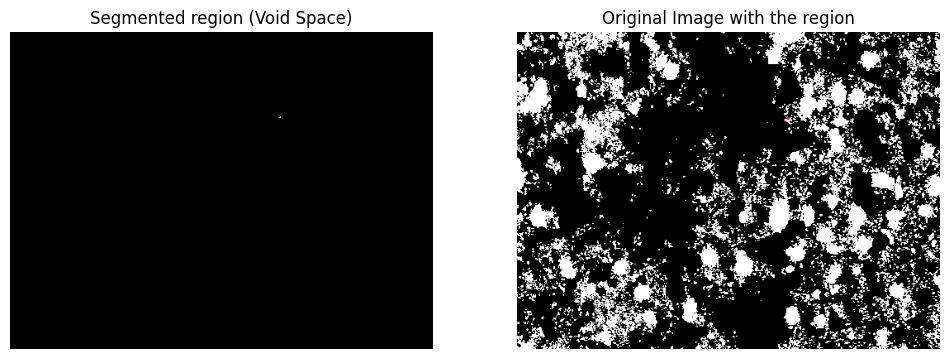

In [22]:
import random
random_number = random.randint(0, len(regioes_segmentadas))  # Generates a random integer between 1 and 100 (inclusive)
print("Random number:", random_number)

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]



# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(regiao_segmentada_desejada, cmap='gray')
plt.title('Segmented region (Void Space)')
plt.axis('off')

plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Original Image with the region')
plt.axis('off')

plt.show()

## Apply the cluster tecnique: k means

In [23]:
# The number of pixels to consider a pore
pore_number = 120

In [24]:
import numpy as np
from sklearn.cluster import KMeans
from skimage.measure import find_contours

def apply_kmeans_to_region(region_segmentada, pore_number):
    # Obter os pixels que são representados por 1 na região segmentada
    pixels_0 = np.argwhere(region_segmentada == 1)

    # Determinar o número de vezes que len(pixels_0) excede pore_number
    excessos = len(pixels_0) // pore_number

    # Ajustar o número de clusters com base nos excessos
    num_clusters = max(1, excessos)

    # Aplicar K-means aos pixels 0 para segmentá-los em clusters
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(pixels_0)

    # Obter os rótulos dos clusters atribuídos aos pixels 0
    labels = kmeans.labels_

    # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

    # Calcular os centros dos clusters
    cluster_centers = kmeans.cluster_centers_

    # Encontrar os contornos de cada cluster
    contornos_por_cluster = []
    for i in range(num_clusters):
        mask = clustered_region == (i + 1)  # Criar uma máscara para o cluster atual
        contornos = find_contours(mask, 0.5)  # Encontrar os contornos do cluster atual
        contornos_por_cluster.append(contornos)

    # Retornar a região clusterizada, o número de clusters, as coordenadas dos centros dos clusters e os contornos de cada cluster
    return clustered_region, num_clusters, cluster_centers, contornos_por_cluster



import numpy as np
from skimage.measure import label, regionprops

def calculate_aspect_ratios(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    aspect_ratios = []
    for region in regions:
        major_axis_length = region.major_axis_length
        minor_axis_length = region.minor_axis_length

        #print(f"Major axis length: {major_axis_length}, Minor axis length: {minor_axis_length}")  # Informações para depuração

        if major_axis_length > 0:  # Evitar divisão por zero
            aspect_ratio = minor_axis_length / major_axis_length
        else:
            aspect_ratio = 0
        aspect_ratios.append(aspect_ratio)

    return aspect_ratios


def calculate_areas(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    #aspect_ratios = []
    areas = []
    for region in regions:
        ##major_axis_length = region.major_axis_length
        ##minor_axis_length = region.minor_axis_length
        area = region.area

        # Calcular a razão de aspecto
        ##if major_axis_length > 0:  # Evitar divisão por zero
        ##    aspect_ratio = minor_axis_length / major_axis_length
        ##else:
        ##    aspect_ratio = 0
        
        ##aspect_ratios.append(aspect_ratio)
        areas.append(area)

    return areas


# Lista para armazenar as coordenadas dos centros de cada região clusterizada
coordenadas_centros_kmeans = []
resultados_kmeans = []
number_of_pores_kmeans = []
ratio_of_aspect_cluster_kmeans = []
areas_cluster_kmeans = []
contour_per_cluster = []

# Plotar as regiões segmentadas após a aplicação do K-means
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    # Aplicar o K-means à região segmentada atual
    clustered_region_kmeans, n_por_kmeans, centros_kmeans, contour_k_means = apply_kmeans_to_region(region_segmentada, pore_number)

    # Armazenar as coordenadas dos centros dos clusters na lista
    coordenadas_centros_kmeans.append(centros_kmeans)
    resultados_kmeans.append(clustered_region_kmeans)
    number_of_pores_kmeans.append(n_por_kmeans)
    # Calcular as razões de aspecto dos clusters
    aspect_ratios_kmeans = calculate_aspect_ratios(clustered_region_kmeans)
    areas_kmeans = calculate_areas(clustered_region_kmeans)
    ratio_of_aspect_cluster_kmeans.append(aspect_ratios_kmeans)
    areas_cluster_kmeans.append(areas_kmeans)
    contour_per_cluster.append(contour_k_means)

In [25]:
len(resultados_kmeans), len(contour_per_cluster), len(number_of_pores_kmeans), len(coordenadas_centros_kmeans)

(2525, 2525, 2525, 2525)

## Separating the void spaces and the pore regions in lists (the index and the centers are saved)

In [26]:
set_of_pores = []
set_of_pores_index = []
set_of_iso_void = []
set_of_iso_void_index = []
set_of_iso_void_centers = []
set_of_pores_centers = []
# First we search the clusters that are a set of "pores"
for i in range(0, len(resultados_kmeans) - 1 ):
    if number_of_pores_kmeans[i] > 1:
        temp_save_pores = number_of_pores_kmeans[i]
        tem_save_pores_centers = coordenadas_centros_kmeans[i]
        temp_save_pores_index = i
        set_of_pores.append(temp_save_pores)
        set_of_pores_index.append(temp_save_pores_index)
        set_of_pores_centers.append(coordenadas_centros_kmeans)
    else:
        temp_save_void = number_of_pores_kmeans[i]
        temp_save_iso_void_centers = coordenadas_centros_kmeans[i]
        temp_save_void_index = i     
        set_of_iso_void.append(temp_save_void)
        set_of_iso_void_index.append(temp_save_void_index)
        set_of_iso_void_centers.append(temp_save_iso_void_centers)

In [27]:
# Checking the length of each list
len(set_of_pores), len(set_of_pores_index), len(set_of_iso_void), len(set_of_iso_void_index)

(40, 40, 2484, 2484)

In [28]:
random_index_check_void = random.randint(0, len(set_of_iso_void_index)-1)
# Checking the code with resultados_kmeans (void spaces)
(resultados_kmeans[set_of_iso_void_index[random_index_check_void]]).max(), set_of_iso_void[random_index_check_void], random_index_check_void

(1.0, 1, 2411)

In [29]:
# Checking the code with resultados_kmeans (pores)
random_index_check_pore = random.randint(0, len(set_of_pores)-1)
(resultados_kmeans[set_of_pores_index[random_index_check_pore]]).max(), set_of_pores[random_index_check_pore], random_index_check_pore, set_of_pores_index[random_index_check_pore]

(5.0, 5, 20, 1171)

In [30]:
region_segmentada.shape

(384, 512)

## Convert the void space into zero values pixels to estimate the tortuosity

In [31]:
# # Função para calcular a distância euclidiana entre dois pontos
# def euclidean_distance(p1, p2):
#     return np.linalg.norm(p1 - p2)

In [32]:
import random
# Number of connected regions acording to the cluster k means
len(set_of_pores)

40

In [33]:
# The code with resultados_kmeans (pores)
random_index_apply_pore = random.randint(0, len(set_of_pores)-1)

In [34]:
resultados_kmeans[0]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

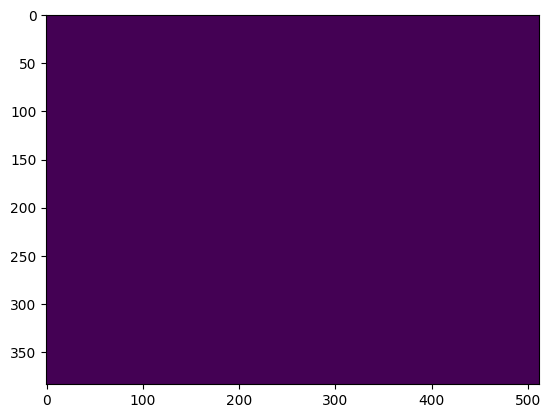

In [35]:
plt.imshow(resultados_kmeans[5])

In [36]:
resultados_kmeans[8].max(), len(coordenadas_centros_kmeans[8])

(1.0, 1)

In [37]:
# saving the list of connected regions to calculate the tortuosity
list_connected_regions = []
list_of_centers_connected_regions = []
c = 0
for i in set_of_pores_index:
    #print(i)
    temp_connected_region = resultados_kmeans[i]
    # Criar o tensor image_temp com valores acima de zero definidos como 1
    # Generate a tensor with image_temp to convert the values greater than zero to one
    temp_connected_region = np.where(temp_connected_region > 0, 1, 0)
    #temp_connected_region = temp_connected_region - 1
    # Inverte the void region to be represented by the zero pixels values
    temp_connected_region = 1 - temp_connected_region 
    temp_center_connected_region = coordenadas_centros_kmeans[i]
    list_connected_regions.append(temp_connected_region)
    list_of_centers_connected_regions.append(temp_center_connected_region)
##    c = c + 1
##    print(i)
##print("The total points", c)

In [38]:
list_connected_regions[0], list_of_centers_connected_regions[0]

(array([[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]]),
 array([[ 17.06730769, 105.47115385],
        [ 53.98214286,  80.1875    ],
        [ 17.4057971 ,  59.78985507],
        [ 67.14736842,  77.23157895],
        [  6.82089552,  82.51492537],
        [  5.9       , 121.12142857],
        [ 17.08333333,  90.04166667],
        [ 48.54545455,  69.23376623],
        [  5.56842105,  55.13684211],
        [ 75.42708333,  78.40625   ],
        [ 31.12903226,  72.2983871 ],
        [ 17.36      , 129.6       ],
        [ 33.64748201,  62.        ],
        [  7.50993377,  70.2781457 ],
        [  5.47887324, 108.02816901],
        [  5.30534351,  95.72519084]]))

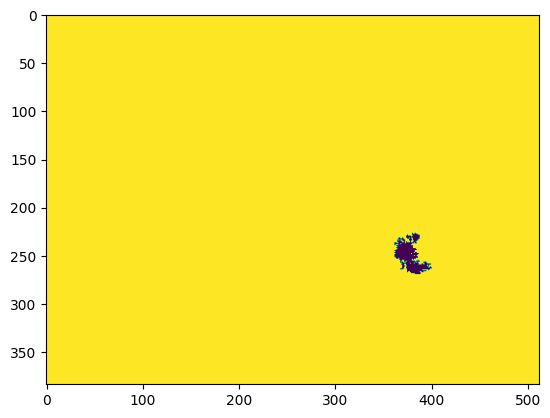

In [39]:
# Showing the connected regions 
random_show_connected =  random.randint(0, len(set_of_pores)-1)
plt.imshow(list_connected_regions[random_show_connected])

In [40]:
temp_connected_region[0]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [41]:
list_of_centers_connected_regions[0]

array([[ 17.06730769, 105.47115385],
       [ 53.98214286,  80.1875    ],
       [ 17.4057971 ,  59.78985507],
       [ 67.14736842,  77.23157895],
       [  6.82089552,  82.51492537],
       [  5.9       , 121.12142857],
       [ 17.08333333,  90.04166667],
       [ 48.54545455,  69.23376623],
       [  5.56842105,  55.13684211],
       [ 75.42708333,  78.40625   ],
       [ 31.12903226,  72.2983871 ],
       [ 17.36      , 129.6       ],
       [ 33.64748201,  62.        ],
       [  7.50993377,  70.2781457 ],
       [  5.47887324, 108.02816901],
       [  5.30534351,  95.72519084]])

In [42]:
list_connected_regions[0]

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]])

[[ 17.06730769 105.47115385]
 [ 53.98214286  80.1875    ]
 [ 17.4057971   59.78985507]
 [ 67.14736842  77.23157895]
 [  6.82089552  82.51492537]
 [  5.9        121.12142857]
 [ 17.08333333  90.04166667]
 [ 48.54545455  69.23376623]
 [  5.56842105  55.13684211]
 [ 75.42708333  78.40625   ]
 [ 31.12903226  72.2983871 ]
 [ 17.36       129.6       ]
 [ 33.64748201  62.        ]
 [  7.50993377  70.2781457 ]
 [  5.47887324 108.02816901]
 [  5.30534351  95.72519084]]


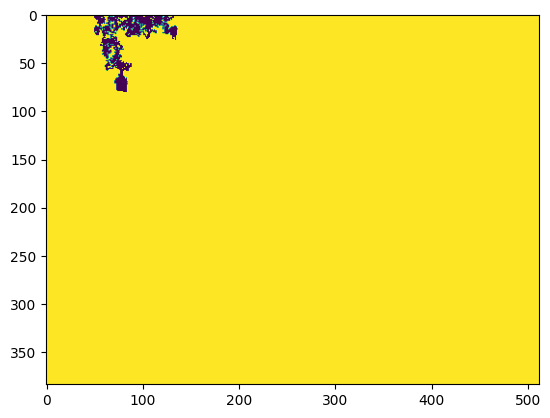

In [43]:
print(list_of_centers_connected_regions[0])
plt.imshow(list_connected_regions[0])

## Apply the route_through_array from skimage to estimate the tortuosity in each void space (pore region)

In [44]:
#This line of code is to save the list_connected_regions that has the clusterized regions
save_list = list_connected_regions
len(save_list)

40

In [45]:
# Run this line of code when you want restart the list to the original pixels
list_connected_regions = save_list

In [46]:
len(list_of_centers_connected_regions), len(list_connected_regions)

(40, 40)

In [47]:
# The optimized code: this is the ideal version because the right path, region and tortuosity
import numpy as np
from skimage.graph import route_through_array
from itertools import combinations

def euclidean_distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

list_tortuosity = []
list_path_distance = []
list_of_path = []
list_max_distance = []
region_with_path = []
for idx in range(len(set_of_pores_index)):
    image_temp = list_connected_regions[idx]
    centers_temp = list_of_centers_connected_regions[idx]
    
    # Inicializar as variáveis para armazenar a maior distância e os centros correspondentes
    max_distance = 0
    farthest_centers = None
    
    # Iterar sobre todas as combinações possíveis de pares de centros
    for (i, j) in combinations(range(len(centers_temp)), 2):
        p1, p2 = centers_temp[i], centers_temp[j]
        dist = euclidean_distance(p1, p2)
        if dist > max_distance:
            max_distance = dist
            farthest_centers = (p1, p2)
    
    if farthest_centers is None:
        # Se não foi encontrado nenhum par de centros, continue para a próxima iteração
        continue
    
    # Coordenadas dos centros dos clusters
    start_float = farthest_centers[0]
    end_float = farthest_centers[1]

    # Converter coordenadas de ponto flutuante para inteiras
    start = (int(round(start_float[0])), int(round(start_float[1])))
    end = (int(round(end_float[0])), int(round(end_float[1])))
    
    try:
       
        # Encontrar o caminho de menor custo
        indices, weight = route_through_array(image_temp, start, end, geometric=True, fully_connected=True)
        indices = np.stack(indices, axis=-1)
        path = np.zeros_like(image_temp)
        path[indices[0], indices[1]] = 1
        
        # Calcular o comprimento do caminho
        path_length = 0
        for k in range(len(indices[0]) - 1):
            x1, y1 = indices[0][k], indices[1][k]
            x2, y2 = indices[0][k + 1], indices[1][k + 1]
            distance_int = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            path_length += distance_int
        
        tortuosity = max_distance / path_length
        
        # Append only valid results to the lists
        list_max_distance.append(max_distance)
        list_of_path.append(path)
        list_path_distance.append(path_length)
        #list_tortuosity.append(tortuosity)
        region_with_path.append(image_temp)
    except ValueError:
        print(f"No minimum-cost path found between {start} and {end}. Skipping this pair.")


In [48]:
# Converter listas para arrays do NumPy
array_path_distance = np.array(list_path_distance)
array_max_distance = np.array(list_max_distance)

# Calcular a tortuosidade
list_tortuosity = array_path_distance / array_max_distance

# Exibir o resultado
print(list_tortuosity)

[2.87418282 4.17666604 2.57038756 1.65549859 1.67175938 1.61137069
 2.90036761 3.07857686 1.32120943 2.22872645 1.5358569  1.52491369
 2.14258567 1.44961761 1.65501111 4.24541379 3.76831135 4.59816153
 2.28877389 1.04092002 2.52138197 1.11823098 1.46771772 1.45183689
 1.59987035 3.50414717 3.49182757 4.43150464 5.0051662  1.57658099
 2.53142377 3.95802568 2.69337536 3.05456301 1.9495282  1.78238212
 1.85589734 1.10936    1.65694285 3.38905334]


In [49]:
len(list_tortuosity), len(list_path_distance), len(list_max_distance), len(list_of_path)

(40, 40, 40, 40)

The index of the cluster in resultados_kmeans: 31
The position of the path: 31 The lengths distance of the path(L2): 69.01219330881973
The distance between the begin and final point of the path (L1): 17.436014547203616
The tortuosity based on the equation (L2/L1): 3.958025678516533


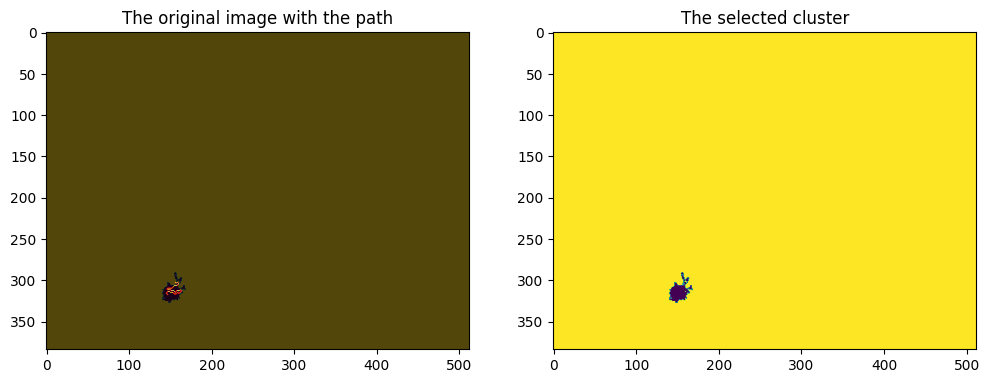

In [50]:
import matplotlib.pyplot as plt
random_show_results =  random.randint(0, len(list_tortuosity)-1)
#random_show_results = 0
# Supondo que 'image_temp' e 'path' já estejam definidos
# E que 'resultados_kmeans' e 'set_of_pores_index[random_index_apply_pore]' já estejam definidos

# Imprimir o índice do cluster
print("The index of the cluster in resultados_kmeans:", random_show_results)
# Imprimir o índice do cluster
print("The position of the path:", random_show_results, "The lengths distance of the path(L2):", list_path_distance[random_show_results])
print("The distance between the begin and final point of the path (L1):", list_max_distance[random_show_results])
print("The tortuosity based on the equation (L2/L1):", list_tortuosity[random_show_results])
# Criar uma figura com duas subfiguras lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 6))



# Mostrar a imagem original com o caminho sobreposto no primeiro subgráfico
axes[0].imshow(region_with_path[random_show_results])  # Mostrar a imagem original
axes[0].imshow(list_of_path[random_show_results], cmap='hot', alpha=0.7)  # Sobrepor o caminho em uma cor diferente e com transparência
axes[0].set_title('The original image with the path')

# Mostrar a imagem do cluster selecionado no segundo subgráfico
axes[1].imshow(region_with_path[random_show_results])
axes[1].set_title('The selected cluster')

# Exibir os gráficos
plt.show()

In [51]:
list_tortuosity.mean()

2.462178178987033

In [52]:
# Inicialize contadores para cada intervalo
intervalo_0_1 = 0
intervalo_1_2 = 0
intervalo_2_3 = 0
intervalo_3_8 = 0

# Itere sobre cada valor na lista
for valor in list_tortuosity:
    if 0 <= valor < 1:
        intervalo_0_1 += 1
    elif 1 <= valor < 2:
        intervalo_1_2 += 1
    elif 2 <= valor < 3:
        intervalo_2_3 += 1
    elif 3 <= valor < 8:
        intervalo_3_8 += 1

# Exibindo os resultados
print(f'Quantidade de valores no intervalo [0, 1): {intervalo_0_1}')
print(f'Quantidade de valores no intervalo [1, 2): {intervalo_1_2}')
print(f'Quantidade de valores no intervalo [2, 3): {intervalo_2_3}')
print(f'Quantidade de valores no intervalo [3, 8): {intervalo_3_8}')

Quantidade de valores no intervalo [0, 1): 0
Quantidade de valores no intervalo [1, 2): 19
Quantidade de valores no intervalo [2, 3): 9
Quantidade de valores no intervalo [3, 8): 12


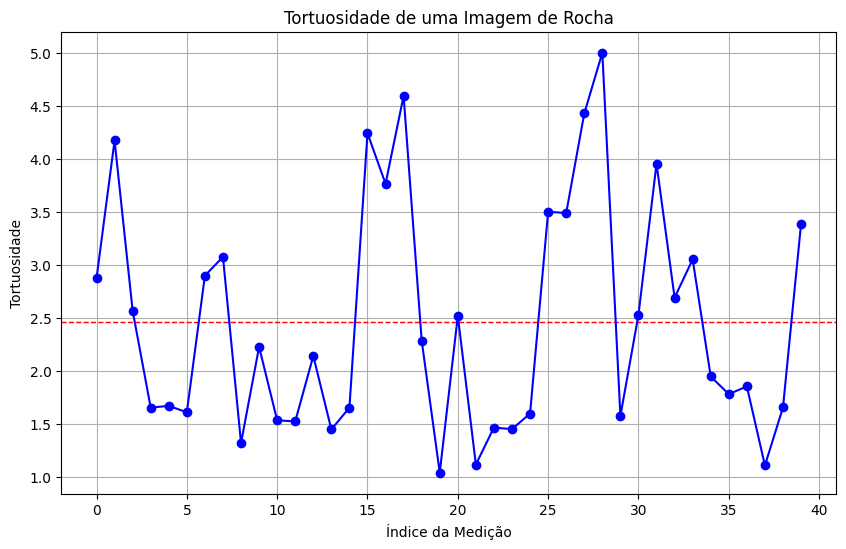

In [53]:
import matplotlib.pyplot as plt

# Criar o gráfico
plt.figure(figsize=(10, 6))


# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(list_tortuosity.mean(), color='red', linestyle='--', linewidth=1)
plt.plot(list_tortuosity, marker='o', linestyle='-', color='b')

# Adicionar título e rótulos aos eixos
plt.title('Tortuosidade de uma Imagem de Rocha')
plt.xlabel('Índice da Medição')
plt.ylabel('Tortuosidade')

# Adicionar grade para melhor visualização
plt.grid(True)

# Exibir o gráfico
plt.show()

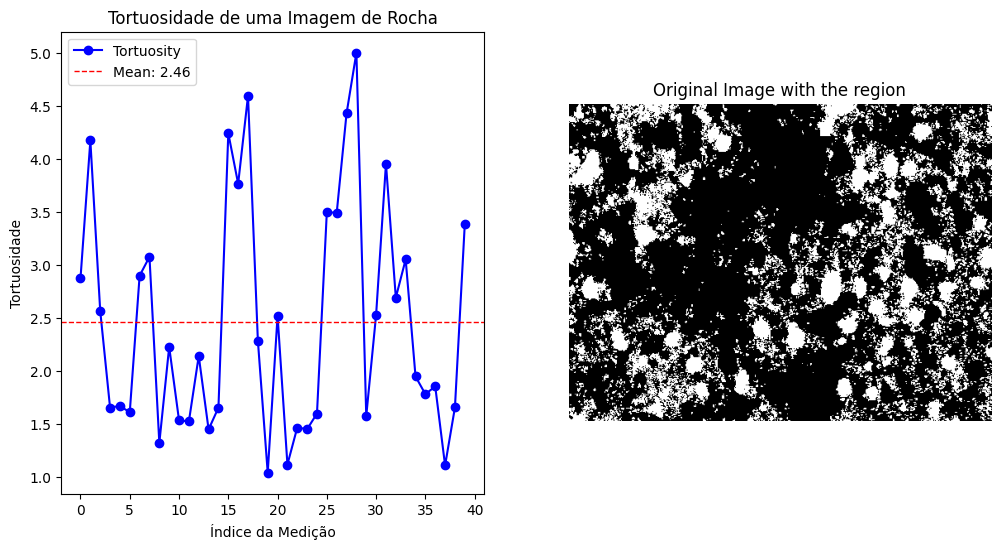

In [54]:
# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))

# Primeiro gráfico: Tortuosidade
plt.subplot(121)
plt.plot(list_tortuosity, marker='o', linestyle='-', color='b', label='Tortuosity')
plt.axhline(list_tortuosity.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {list_tortuosity.mean():.2f}')

# Adicionar título e rótulos aos eixos
plt.title('Tortuosidade de uma Imagem de Rocha')
plt.xlabel('Índice da Medição')
plt.ylabel('Tortuosidade')

# Adicionar legenda
plt.legend()

# Segundo gráfico: Imagem binária com a região
plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.title('Original Image with the region')
plt.axis('off')

# Exibir o gráfico
plt.show()

## Apply the bfs (Breadth-First Search) to estimate the tortuosity in each void space (pore region)

In [55]:
import numpy as np
from collections import deque
from itertools import combinations

def euclidean_distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

def bfs_path(image, start, end):
    rows, cols = image.shape
    visited = np.full((rows, cols), False)
    parent = np.full((rows, cols, 2), -1, dtype=int)
    
    # Movimentos possíveis: cima, baixo, esquerda, direita
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    
    queue = deque([start])
    visited[start[0], start[1]] = True
    
    while queue:
        current = queue.popleft()
        
        if current == end:
            break
        
        for d in directions:
            nr, nc = current[0] + d[0], current[1] + d[1]
            
            if 0 <= nr < rows and 0 <= nc < cols and not visited[nr, nc] and image[nr, nc] == 0:
                queue.append((nr, nc))
                visited[nr, nc] = True
                parent[nr, nc] = current
    
    path = []
    if visited[end[0], end[1]]:
        current = end
        while current != start:
            path.append(current)
            current = tuple(parent[current[0], current[1]])
        path.append(start)
        path.reverse()
    
    return path

In [56]:
list_tortuosity = []
list_path_distance = []
list_of_path = []
list_max_distance = []
region_with_path = []

for idx in range(len(set_of_pores_index)):
    image_temp = list_connected_regions[idx]
    centers_temp = list_of_centers_connected_regions[idx]
    
    # Inicializar as variáveis para armazenar a maior distância e os centros correspondentes
    max_distance = 0
    farthest_centers = None
    
    # Iterar sobre todas as combinações possíveis de pares de centros
    for (i, j) in combinations(range(len(centers_temp)), 2):
        p1, p2 = centers_temp[i], centers_temp[j]
        dist = euclidean_distance(p1, p2)
        if dist > max_distance:
            max_distance = dist
            farthest_centers = (p1, p2)
    
    if farthest_centers is None:
        # Se não foi encontrado nenhum par de centros, continue para a próxima iteração
        continue
    
    # Coordenadas dos centros dos clusters
    start_float = farthest_centers[0]
    end_float = farthest_centers[1]

    # Converter coordenadas de ponto flutuante para inteiras
    start = (int(round(start_float[0])), int(round(start_float[1])))
    end = (int(round(end_float[0])), int(round(end_float[1])))
    
    try:
        # Encontrar o caminho de menor custo usando BFS
        path = bfs_path(image_temp, start, end)
        if not path:
            print(f"No path found between {start} and {end}. Skipping this pair.")
            continue
        
        # Marcar o caminho na imagem
        path_array = np.zeros_like(image_temp)
        for r, c in path:
            path_array[r, c] = 1
        
        # Calcular o comprimento do caminho
        path_length = 0
        for k in range(len(path) - 1):
            x1, y1 = path[k]
            x2, y2 = path[k + 1]
            distance_int = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            path_length += distance_int
        
        tortuosity = path_length / max_distance
        
        # Append only valid results to the lists
        list_max_distance.append(max_distance)
        list_of_path.append(path_array)
        list_path_distance.append(path_length)
        #list_tortuosity.append(tortuosity)
        region_with_path.append(image_temp)
    except ValueError:
        print(f"No path found between {start} and {end}. Skipping this pair.")

No path found between (62, 6) and (99, 23). Skipping this pair.
No path found between (98, 121) and (182, 84). Skipping this pair.
No path found between (192, 474) and (171, 436). Skipping this pair.
No path found between (318, 147) and (303, 156). Skipping this pair.
No path found between (327, 207) and (347, 219). Skipping this pair.


In [57]:
# Converter listas para arrays do NumPy
array_path_distance = np.array(list_path_distance)
array_max_distance = np.array(list_max_distance)

# Calcular a tortuosidade
list_tortuosity = array_path_distance / array_max_distance

# Exibir o resultado
print(list_tortuosity)

[1.93626843 1.3443426  1.48398509 1.53597307 1.2904405  1.56456575
 1.51873016 2.1290068  1.16012237 1.72572672 1.38952709 0.98971884
 1.43332374 1.04724522 1.35193721 1.27158565 1.47208322 1.26667971
 1.38548084 1.37269903 1.28762143 1.5125951  1.46090376 1.20050596
 1.05407535 1.33753356 1.4700542  1.54596725 1.34821413 1.85619038
 1.97396011 0.99097878 1.3447474  1.42186748 1.1540655 ]


In [58]:
#To comparison with (sinthetic model)
region_with_path[1].max(), region_with_path[1].min()

(1, 0)

In [59]:
len(list_tortuosity), len(list_path_distance), len(list_max_distance), len(list_of_path)

(35, 35, 35, 35)

In [60]:
max(list_max_distance), min(list_max_distance)

(106.74490080104958, 8.923609011683261)

In [61]:
len(list_tortuosity)

35

The index of the cluster in resultados_kmeans: 6
The position of the path: 6 The lengths distance of the path(L2): 70.0
The distance between the begin and final point of the path (L1): 46.091137052780404
The tortuosity based on the equation (L2/L1): 1.518730161068511


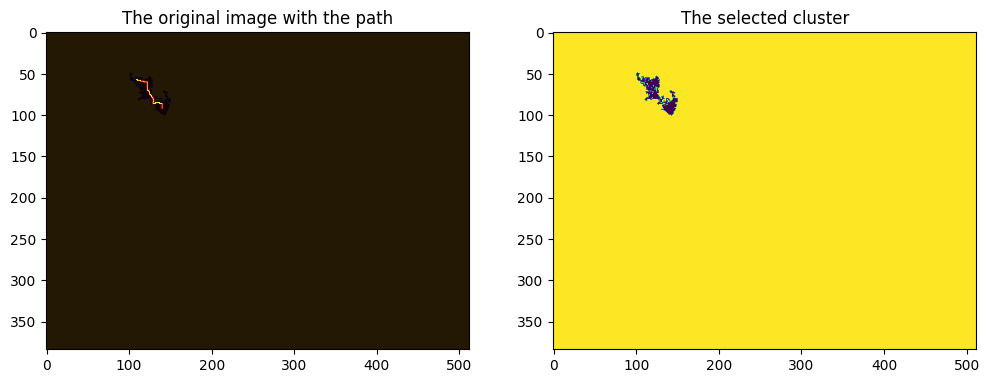

In [121]:
import matplotlib.pyplot as plt
random_show_results =  random.randint(0, len(list_tortuosity)-1)
#random_show_results = 0
# Supondo que 'image_temp' e 'path' já estejam definidos
# E que 'resultados_kmeans' e 'set_of_pores_index[random_index_apply_pore]' já estejam definidos

# Imprimir o índice do cluster
print("The index of the cluster in resultados_kmeans:", random_show_results)
# Imprimir o índice do cluster
print("The position of the path:", random_show_results, "The lengths distance of the path(L2):", list_path_distance[random_show_results])
print("The distance between the begin and final point of the path (L1):", list_max_distance[random_show_results])
print("The tortuosity based on the equation (L2/L1):", list_tortuosity[random_show_results])
# Criar uma figura com duas subfiguras lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 6))



# Mostrar a imagem original com o caminho sobreposto no primeiro subgráfico
axes[0].imshow(region_with_path[random_show_results])  # Mostrar a imagem original
axes[0].imshow(list_of_path[random_show_results], cmap='hot', alpha=0.9)  # Sobrepor o caminho em uma cor diferente e com transparência
axes[0].set_title('The original image with the path')

# Mostrar a imagem do cluster selecionado no segundo subgráfico
axes[1].imshow(region_with_path[random_show_results])
axes[1].set_title('The selected cluster')

# Exibir os gráficos
plt.show()

In [119]:
list_tortuosity_np = np.array(list_tortuosity)

In [64]:
list_tortuosity_np.mean()

1.417963497444233

In [65]:
# Inicialize contadores para cada intervalo
intervalo_0_1 = 0
intervalo_1_2 = 0
intervalo_2_3 = 0
intervalo_3_8 = 0

# Itere sobre cada valor na lista
for valor in list_tortuosity:
    if 0 <= valor < 1:
        intervalo_0_1 += 1
    elif 1 <= valor < 2:
        intervalo_1_2 += 1
    elif 2 <= valor < 3:
        intervalo_2_3 += 1
    elif 3 <= valor < 8:
        intervalo_3_8 += 1

# Exibindo os resultados
print(f'Quantidade de valores no intervalo [0, 1): {intervalo_0_1}')
print(f'Quantidade de valores no intervalo [1, 2): {intervalo_1_2}')
print(f'Quantidade de valores no intervalo [2, 3): {intervalo_2_3}')
print(f'Quantidade de valores no intervalo [3, 8): {intervalo_3_8}')

Quantidade de valores no intervalo [0, 1): 2
Quantidade de valores no intervalo [1, 2): 32
Quantidade de valores no intervalo [2, 3): 1
Quantidade de valores no intervalo [3, 8): 0


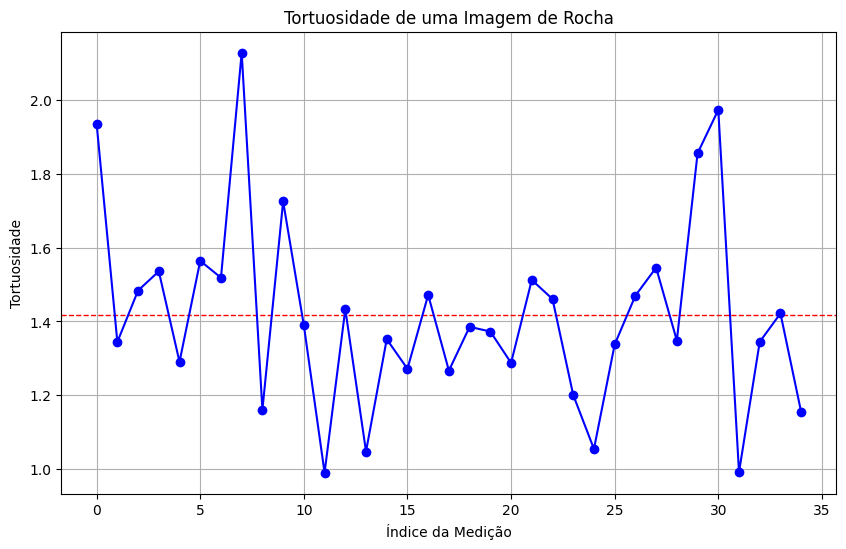

In [66]:
import matplotlib.pyplot as plt

# Criar o gráfico
plt.figure(figsize=(10, 6))


# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(list_tortuosity_np.mean(), color='red', linestyle='--', linewidth=1)
plt.plot(list_tortuosity_np, marker='o', linestyle='-', color='b')

# Adicionar título e rótulos aos eixos
plt.title('Tortuosidade de uma Imagem de Rocha')
plt.xlabel('Índice da Medição')
plt.ylabel('Tortuosidade')

# Adicionar grade para melhor visualização
plt.grid(True)

# Exibir o gráfico
plt.show()

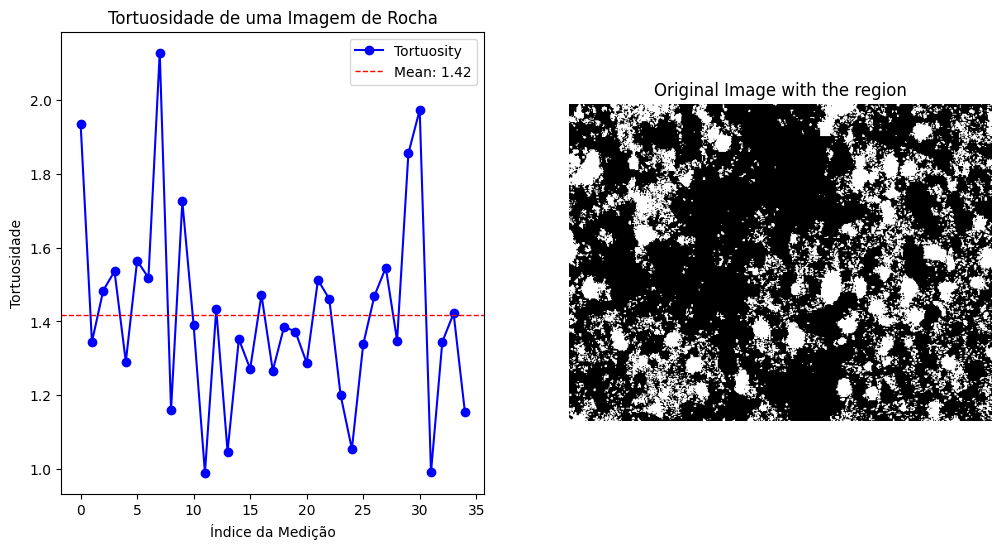

In [67]:
# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))

# Primeiro gráfico: Tortuosidade
plt.subplot(121)
plt.plot(list_tortuosity_np, marker='o', linestyle='-', color='b', label='Tortuosity')
plt.axhline(list_tortuosity_np.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {list_tortuosity_np.mean():.2f}')

# Adicionar título e rótulos aos eixos
plt.title('Tortuosidade de uma Imagem de Rocha')
plt.xlabel('Índice da Medição')
plt.ylabel('Tortuosidade')

# Adicionar legenda
plt.legend()

# Segundo gráfico: Imagem binária com a região
plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.title('Original Image with the region')
plt.axis('off')

# Exibir o gráfico
plt.show()